pip install lightrag-hku
pip install nest-asyncio
pip install sentence-transformers
pip install networkx matplotlib pyvis

In [ ]:
import os
import asyncio
import nest_asyncio
import numpy as np

from lightrag import LightRAG, QueryParam
from lightrag.utils import EmbeddingFunc
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from sentence_transformers import SentenceTransformer

In [2]:
# Jupyter 환경 등에서 비동기 충돌 방지
nest_asyncio.apply()

In [3]:
# 1. Gemini API 키 설정
os.environ["GOOGLE_API_KEY"] = "AQ.Ab8RN6KfiEJM8LmRBiZfX5d_StkYr-3cAG2-K2Z0VQ090wtpFw"

In [4]:
# 2. LangChain을 이용한 LLM 및 임베딩 초기화
print("LangChain LLM 및 로컬 임베딩 모델을 초기화합니다...")
# 텍스트 생성용 모델 (추출 및 요약)
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
# 텍스트 벡터화 모델 (유사도 검색용)
local_embedder = SentenceTransformer("jhgan/ko-sroberta-multitask")

LangChain LLM 및 로컬 임베딩 모델을 초기화합니다...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [5]:
# 3. LightRAG 연결용 커스텀 함수 (LLM 부분은 기존과 동일)
async def gemini_llm_func(prompt, system_prompt=None, history_messages=[], **kwargs) -> str:
    messages = []
    if system_prompt:
        messages.append(("system", system_prompt))
    for msg in history_messages:
        role = "human" if msg.get("role") == "user" else "ai"
        messages.append((role, msg.get("content", "")))
    messages.append(("human", prompt))
    
    response = await asyncio.to_thread(llm.invoke, messages)
    content = response.content
    if isinstance(content, list):
        text_result = ""
        for item in content:
            if isinstance(item, str):
                text_result += item
            elif isinstance(item, dict) and "text" in item:
                text_result += item["text"]
        return text_result
    return str(content)

async def local_embedding_func(texts: list[str]) -> np.ndarray:
    embeddings = await asyncio.to_thread(local_embedder.encode, texts)
    return np.array(embeddings)

In [6]:
# 4. 작업 디렉토리 설정
WORKING_DIR = "./lightrag_workspace_final"
if not os.path.exists(WORKING_DIR):
    os.mkdir(WORKING_DIR)

In [7]:
# 5. LightRAG 인스턴스 초기화 (수정된 함수 연결)
print("LightRAG 시스템을 재초기화합니다...")
rag = LightRAG(
    working_dir=WORKING_DIR,
    llm_model_func=gemini_llm_func, 
    llm_model_max_async=4,
    embedding_func=EmbeddingFunc(
        embedding_dim=768, # 다행히 이 한국어 모델도 구글과 똑같은 768차원입니다!
        max_token_size=8192,
        func=local_embedding_func # <- 이름 변경 적용
    )
)

print("스토리지 파이프라인을 초기화합니다...")
await rag.initialize_storages()

LightRAG 시스템을 재초기화합니다...


INFO: [] Created new empty graph file: ./lightrag_workspace_final\graph_chunk_entity_relation.graphml
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './lightrag_workspace_final\\vdb_entities.json'} 0 data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './lightrag_workspace_final\\vdb_relationships.json'} 0 data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './lightrag_workspace_final\\vdb_chunks.json'} 0 data
INFO: Role LLM Configuration (initialized):
INFO:  - extract: None/None, host=None, max_async=4, timeout=240
INFO:  - keyword: None/None, host=None, max_async=4, timeout=240
INFO:  - query: None/None, host=None, max_async=4, timeout=240
INFO:  - vlm: None/None, host=None, max_async=4, timeout=240
INFO: [] Process 3044 KV load full_docs with 0 records
INFO: [] Process 3044 KV load text_chunks with 0 records
INFO: [] Process 3044 KV load full_entities with 0 records
INFO: [] 

스토리지 파이프라인을 초기화합니다...


In [8]:
# 6. 데이터 삽입 및 지식 그래프 생성
sample_text = """
[대한민국 민법: 상속 및 이혼 관련 일상생활 법률 (최종)]

1. 법정상속순위와 상속분
피상속인(사망자)이 유언 없이 사망한 경우 민법에 따라 상속이 이루어진다. 제1순위 상속인은 피상속인의 직계비속(자녀, 손자녀 등)과 배우자이며, 제2순위는 피상속인의 직계존속(부모, 조부모 등)과 배우자이다. 만약 직계비속과 직계존속이 모두 없는 경우 배우자가 단독 상속인이 된다. 
상속재산을 나눌 때, 배우자의 상속분은 직계비속이나 직계존속의 상속분에 5할(0.5)을 가산한다. 즉, 배우자와 자녀가 공동 상속받을 경우 그 비율은 1.5 대 1이 된다.

2. 상속포기와 한정승인
상속인은 피상속인의 재산뿐만 아니라 채무(빚)도 함께 물려받는다. 만약 물려받을 빚이 재산보다 많다면 상속인은 상속개시 있음을 안 날로부터 3개월 이내에 가정법원에 '상속포기' 또는 '한정승인'을 신고할 수 있다. 한정승인은 상속받은 재산의 한도 내에서만 피상속인의 빚을 갚겠다는 조건부 승인이다.

3. 이혼과 재산분할청구권
부부가 이혼할 때, 혼인 기간 중 공동으로 형성한 재산에 대해 '재산분할'을 청구할 수 있다. 이는 협의이혼과 재판상 이혼 모두에 적용된다. 재산분할 비율은 재산 형성에 대한 기여도(가사노동 등 포함), 혼인 기간, 연령 등을 종합적으로 고려하여 가정법원이 산정한다. 단, 재산분할청구권은 이혼한 날부터 2년이 경과하면 소멸하므로 주의해야 한다.

4. 미성년 자녀의 친권 및 양육권
이혼 시 미성년 자녀가 있는 경우, 부모는 협의로 친권자와 양육자를 정해야 하며, 협의가 이루어지지 않으면 가정법원이 자녀의 복리를 최우선으로 고려하여 이를 지정한다. 비양육친(양육하지 않는 부모)은 자녀를 만나거나 연락할 수 있는 '면접교섭권'을 가지며, 양육친에게 일정 금액의 '양육비'를 지급할 의무를 진다.
"""

In [9]:
print("법률 지식 그래프 구축을 시작합니다... (잠시만 기다려주세요)")
await rag.ainsert(sample_text)
print("지식 그래프 구축 완료!\n")

INFO: Processing 1 document(s)
INFO: Parsing (native): doc-2d2fc92ce2ae73244fc4787dbef49b9f
INFO: Extracting stage 1/1: unknown_source
INFO: Processing d-id: doc-2d2fc92ce2ae73244fc4787dbef49b9f
INFO: Chunking F(legacy): size=1200, split_only=False, overlap=100, doc_id: doc-2d2fc92ce2ae73244fc4787dbef49b9f
INFO: extract LLM func: 4 new workers initialized (Timeouts: Func: 240s, Worker: 480s, Health Check: 495s)
INFO:google_genai.models:AFC is enabled with max remote calls: 10.


법률 지식 그래프 구축을 시작합니다... (잠시만 기다려주세요)


INFO:  == LLM cache == saving: default:extract:477b6ba0f8785795447674a6ac11cf71
INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:  == LLM cache == saving: default:extract:c446535fde0c4452368ff566b1bf31ad
INFO: Chunk 1 of 1 extracted 19 Ent + 16 Rel doc-2d2fc92ce2ae73244fc4787dbef49b9f-chunk-000
INFO: Merging stage 1/1: unknown_source
INFO: Phase 0: Writing recovery indexes for doc-2d2fc92ce2ae73244fc4787dbef49b9f: 19 candidate entities, 16 candidate relations
INFO: Phase 1: Processing 19 entities from doc-2d2fc92ce2ae73244fc4787dbef49b9f (async: 8)
INFO: Phase 2: Processing 16 relations from doc-2d2fc92ce2ae73244fc4787dbef49b9f (async: 8)
INFO: Upserting relation VDB: `가정법원->대한민국 민법`
INFO: Upserting relation VDB: `제1순위 상속인->직계비속`
INFO: Upserting relation VDB: `제2순위 상속인->직계존속`
INFO: Upserting relation VDB: `대한민국 민법->재산분할청구권`
INFO: Upserting relation VDB: `가정법원->상속포기`
INFO: Upserting relation VDB: `배우자->제1순위 상속인`
INFO: Upserting relation VDB: `상속인->피상속인`
INFO: Upse

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO: In memory DB persist to disk
INFO: Completed processing file 1/1: unknown_source
INFO: Enqueued document processing pipeline stopped


지식 그래프 구축 완료!



In [10]:
# 8. 검색 쿼리 테스트
print("="*50)
print("[Test 1: 조건부 기한 및 대처법 (Local Search)]")
ans_1 = await rag.aquery(
    "남편이 빚을 많이 남기고 사망했습니다. 아내가 빚을 떠안지 않으려면 어떻게 해야 하나요?", 
    param=QueryParam(mode="local")
)
print(f"답변:\n{ans_1}\n")

INFO: keyword LLM func: 4 new workers initialized (Timeouts: Func: 240s, Worker: 480s, Health Check: 495s)
INFO:google_genai.models:AFC is enabled with max remote calls: 10.


[Test 1: 조건부 기한 및 대처법 (Local Search)]


INFO:  == LLM cache == saving: local:keywords:23fa23be603407a99805befe7acbd357


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO: Query nodes: 남편, 아내 (top_k:40, cosine:0.2)
INFO: Local query: 18 entites, 16 relations
INFO: Raw search results: 18 entities, 16 relations, 0 vector chunks
INFO: After truncation: 18 entities, 16 relations
INFO: Selecting 1 from 1 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 16 relations
INFO: Round-robin merged chunks: 1 -> 1 (deduplicated 0)
INFO: Final context: 18 entities, 16 relations, 1 chunks
INFO: Final chunks S+F/O: E18/1
INFO: query LLM func: 4 new workers initialized (Timeouts: Func: 240s, Worker: 480s, Health Check: 495s)
INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:  == LLM cache == saving: local:query:75e960c776aad28f19330e22dd9a03b7


답변:
피상속인(사망자)이 재산보다 빚을 많이 남기고 사망한 경우, 상속인은 피상속인의 빚을 함께 물려받지 않기 위해 **상속개시 있음을 안 날로부터 3개월 이내에 가정법원에 '상속포기' 또는 '한정승인'을 신고**할 수 있습니다. 

구체적인 내용은 다음과 같습니다.

* **상속포기**: 상속인의 지위를 포기하여 빚을 포함한 모든 상속 재산을 받지 않는 방법입니다.
* **한정승인**: 상속받은 재산의 한도 내에서만 피상속인의 빚을 갚겠다는 조건부로 상속을 승인하는 방법입니다.

이러한 신고는 기한 내에 가정법원에 해야 하므로 주의가 필요합니다.

### References

- [] 대한민국 민법: 상속 및 이혼 관련 일상생활 법률 (최종)



In [11]:
print("="*50)
print("[Test 2: 수치 계산 및 관계 추론 (Hybrid Search)]")
ans_2 = await rag.aquery(
    "아버지가 돌아가셨고, 유가족으로 어머니와 아들 1명이 있습니다. 상속 비율은 어떻게 되나요?", 
    param=QueryParam(mode="hybrid")
)
print(f"답변:\n{ans_2}\n")

INFO:google_genai.models:AFC is enabled with max remote calls: 10.


[Test 2: 수치 계산 및 관계 추론 (Hybrid Search)]


INFO:  == LLM cache == saving: hybrid:keywords:5cce8e674dfd39964ce8b1a71a001203


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO: Query nodes: 아버지, 어머니, 아들, 유가족 (top_k:40, cosine:0.2)
INFO: Local query: 19 entites, 16 relations
INFO: Query edges: 상속, 상속 비율 (top_k:40, cosine:0.2)
INFO: Global query: 17 entites, 16 relations
INFO: Raw search results: 19 entities, 16 relations, 0 vector chunks
INFO: After truncation: 19 entities, 16 relations
INFO: Selecting 1 from 1 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 16 relations
INFO: Round-robin merged chunks: 1 -> 1 (deduplicated 0)
INFO: Final context: 19 entities, 16 relations, 1 chunks
INFO: Final chunks S+F/O: E19/1
INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:  == LLM cache == saving: hybrid:query:8fd72b63f004090f04794353066a12a2


답변:
대한민국 민법에 따르면, 피상속인(사망자)이 유언 없이 사망한 경우 상속 순위와 비율은 다음과 같이 결정됩니다.

* **제1순위 상속인**: 피상속인의 직계비속(자녀, 손자녀 등)과 배우자입니다. 질문하신 사례의 경우, 유가족으로 어머니(배우자)와 아들 1명(직계비속)이 있으므로 두 분이 공동으로 제1순위 상속인이 됩니다.
* **상속 비율**: 상속재산을 나눌 때 배우자의 상속분은 직계비속의 상속분에 5할(0.5)을 가산합니다. 따라서 어머니와 자녀가 공동 상속받을 경우, 상속 비율은 **어머니 1.5 : 아들 1** (즉, 3:2 비율)이 됩니다.

### References



In [12]:
print("="*50)
print("[Test 3: 문서 전체 맥락 요약 (Global Search)]")
ans_3 = await rag.aquery(
    "미성년 자녀가 있는 부부가 이혼할 때, 부모 각각이 가지는 권리와 의무를 요약해 줘.", 
    param=QueryParam(mode="global")
)
print(f"답변:\n{ans_3}\n")
print("="*50)

INFO:google_genai.models:AFC is enabled with max remote calls: 10.


[Test 3: 문서 전체 맥락 요약 (Global Search)]


INFO:  == LLM cache == saving: global:keywords:bb8422e08f99c938f28519f3f4c7ccc1


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO: Query edges: 미성년 자녀, 부부 이혼, 권리와 의무 (top_k:40, cosine:0.2)
INFO: Global query: 17 entites, 16 relations
INFO: Raw search results: 17 entities, 16 relations, 0 vector chunks
INFO: After truncation: 17 entities, 16 relations
INFO: Selecting 1 from 1 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 16 relations
INFO: Round-robin merged chunks: 1 -> 1 (deduplicated 0)
INFO: Final context: 17 entities, 16 relations, 1 chunks
INFO: Final chunks S+F/O: E17/1
INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:  == LLM cache == saving: global:query:b56364cda27408402c9a5b69f35a1949


답변:
미성년 자녀가 있는 부부가 이혼할 때 부모가 가지는 권리와 의무는 다음과 같습니다.

* **친권자 및 양육자 지정**: 이혼 시 미성년 자녀가 있는 경우 부모는 협의를 통해 친권자와 양육자를 정해야 합니다. 만약 협의가 이루어지지 않을 경우, 가정법원이 자녀의 복리를 최우선으로 고려하여 이를 지정합니다.
* **면접교섭권 (비양육친)**: 양육을 하지 않는 부모인 비양육친은 이혼 후에도 자녀를 직접 만나거나 연락할 수 있는 '면접교섭권'을 가집니다.
* **양육비 지급 의무 (비양육친)**: 비양육친은 양육을 맡은 부모(양육친)에게 미성년 자녀를 기르는 데 필요한 비용인 '양육비'를 일정 금액 지급할 의무를 집니다.

### References

- [] 대한민국 민법: 상속 및 이혼 관련 일상생활 법률 (최종)



INFO:matplotlib.font_manager:generated new fontManager


knowledge_graph.png 파일로 저장되었습니다!


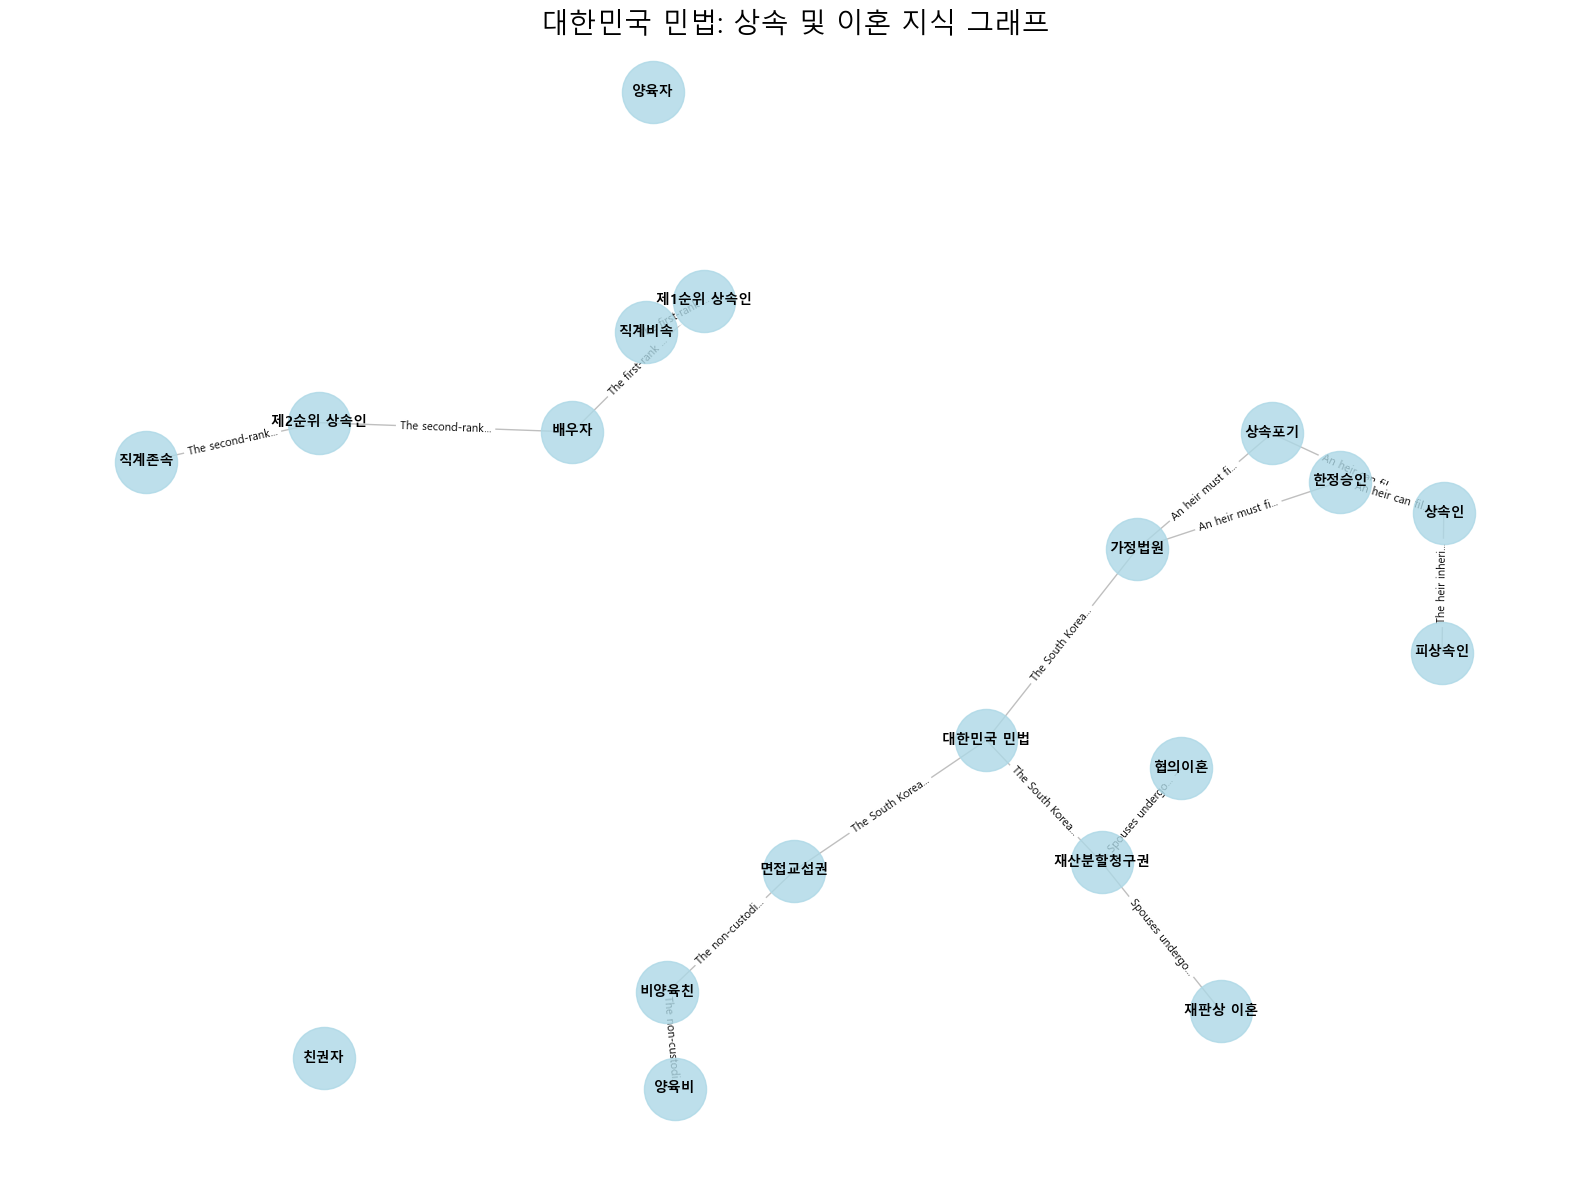

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows 사용자용)
# 에러 로그에서 Windows를 사용 중이신 것으로 확인되어 맑은 고딕으로 설정합니다.
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. GraphML 파일 읽기
WORKING_DIR = "./lightrag_workspace_final"
graph_path = os.path.join(WORKING_DIR, "graph_chunk_entity_relation.graphml")
G = nx.read_graphml(graph_path)

# 2. 도화지 크기 설정
plt.figure(figsize=(16, 12))

# 3. 노드 위치 계산 (spring_layout이 노드를 보기 좋게 퍼뜨려줍니다)
pos = nx.spring_layout(G, k=0.5, iterations=50)

# 4. 그래프 그리기
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color='gray')

# 노드 이름(라벨) 그리기
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Malgun Gothic', font_weight='bold')

# (옵션) 엣지의 관계(label) 그리기
edge_labels = nx.get_edge_attributes(G, 'description')
# 텍스트가 너무 길면 보기 힘드므로, 앞에서 15글자 정도만 자르기
short_edge_labels = {k: v[:15] + "..." for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=short_edge_labels, font_size=8, font_family='Malgun Gothic')

# 5. 이미지 저장 및 출력
plt.title("대한민국 민법: 상속 및 이혼 지식 그래프", fontsize=20)
plt.axis('off') # 축 숨기기
plt.tight_layout()

# png 파일로 저장
plt.savefig("knowledge_graph.png", dpi=300)
print("knowledge_graph.png 파일로 저장되었습니다!")

plt.show()